In [1]:
import os
import glob

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import MDAnalysis as mda
from tqdm import tqdm
from numpy import linalg as LA
from MDAnalysis.analysis import align
from matplotlib.ticker import FuncFormatter

%run ~/.mpl_358.py

import pyemma

In [2]:
df_all = pd.read_pickle("./df_comp_kmeans_mod.pkl")
df_all

,sys_name,frame,n_res,dist,n_contacts,rmsd,rmsd_nsp10,rmsd_nsp16,labels,mod
0,comp_0,0,415,32.605477,143,1.270958,1.157980,1.061589,453,1
1,comp_0,1,415,32.323373,144,1.266247,1.135788,1.180746,228,0
2,comp_0,2,415,31.932924,156,1.251338,1.298619,1.130007,448,0
3,comp_0,3,415,32.521470,149,1.232570,1.067588,1.155031,59,0
4,comp_0,4,415,32.193099,157,1.497461,1.652155,1.348938,183,0
...,...,...,...,...,...,...,...,...,...,...
83995,comp_100,3995,415,39.647390,107,10.644501,5.009146,2.698992,283,4
83996,comp_100,3996,415,39.943104,114,10.607467,4.521076,2.744293,102,4
83997,comp_100,3997,415,39.952250,113,10.840326,4.824111,2.710605,72,4
83998,comp_100,3998,415,40.436388,108,10.780112,4.630009,2.768572,72,4


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


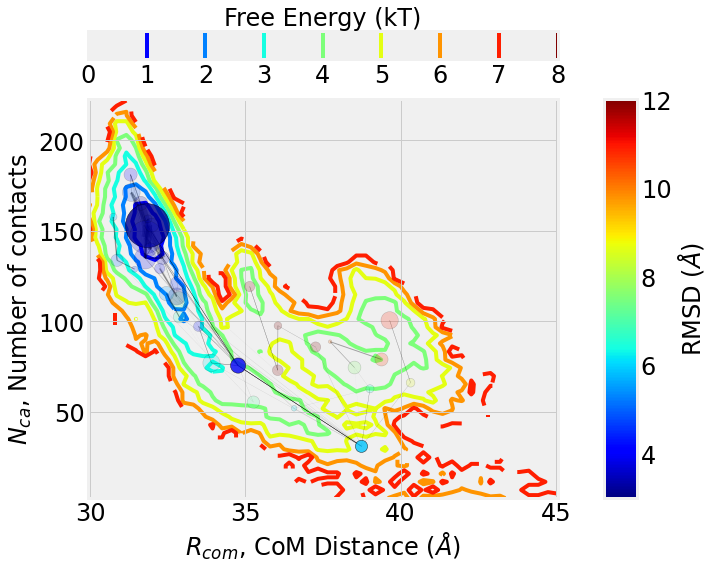

In [3]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10,8))
divider = make_axes_locatable(ax)
path_ind = [0, 17, 7]

x, y, z = pyemma.plots.plots2d.get_histogram(
    df_all['dist'], df_all['n_contacts'],
    nbins=50, weights=None,
    avoid_zero_count=False)
f = pyemma.plots.plots2d._to_free_energy(z, minener_zero=False) * 1.
f -= np.min(f)
[X, Y] = np.meshgrid(x, y)
CT = ax.contour(X, Y, f, cmap='jet', zorder=0)

cax_CT = divider.append_axes("top", size="7%", pad="10%")
cbar_ = fig.colorbar(CT, cax=cax_CT, orientation='horizontal') 
cbar_.ax.set_title(r'Free Energy (kT)')
#     cbar_.xaxis.set_ticks_position("top")

# graph
G = nx.read_gexf("./nsp10_16_kmeans_mod.gexf")
nodes = G.nodes.data()
df = pd.DataFrame([node[1] for node in nodes])
df = df.astype({
    'label': int, 
    "dist_mean": float,
    'rmsd_mean': float,
    'n_contacts_mean': float,
    "count": int})

edges = G.edges.data()   
for edge in edges:
    source, target = int(edge[0]), int(edge[1])
    if source == target: 
        continue

    weight = edge[2]['weight']
    sub_df = df[(df.label == source) | (df.label == target)]
    alpha = 1 if (source in path_ind) & (target in path_ind) else .3

    sub_xy = sub_df[['dist_mean', 'n_contacts_mean']].to_numpy()
    ax.plot(sub_xy[:,0], sub_xy[:,1], color='black', linewidth=weight*50, alpha=alpha, zorder=1)

node_xy = df[['dist_mean', 'n_contacts_mean']].to_numpy()
alphas = np.ones(len(node_xy)) * .2
alphas[path_ind] = .8
CS = ax.scatter(node_xy[:,0], node_xy[:,1], c=df['rmsd_mean'], 
               s=df['count']/10, 
                zorder=3, edgecolor='k', 
           cmap='jet', alpha=alphas, 
            vmin=3, vmax=12)
cax_CS = divider.append_axes("right", size="7%", pad="10%")
cbar_ = fig.colorbar(CS, cax=cax_CS) 
#     cbar_.ax.set_title(r'Free Energy (kT)')
#     cbar_ = fig.colorbar(CS, ax=ax,)
cbar_.ax.set_ylabel(r'RMSD ($\AA$)')

ax.set_xlabel(r'$R_{com}$, CoM Distance ($\AA$)')
ax.set_ylabel(r'$N_{ca}$, Number of contacts')


fig.tight_layout()
fig.savefig(f'dist_contact_cluster.png', dpi=300, bbox_inches='tight')



In [19]:
Y

array([[  2.25,   2.25,   2.25, ...,   2.25,   2.25,   2.25],
       [  6.75,   6.75,   6.75, ...,   6.75,   6.75,   6.75],
       [ 11.25,  11.25,  11.25, ...,  11.25,  11.25,  11.25],
       ...,
       [213.75, 213.75, 213.75, ..., 213.75, 213.75, 213.75],
       [218.25, 218.25, 218.25, ..., 218.25, 218.25, 218.25],
       [222.75, 222.75, 222.75, ..., 222.75, 222.75, 222.75]])

Text(0.5, 1.0, 'Simplest default with labels')

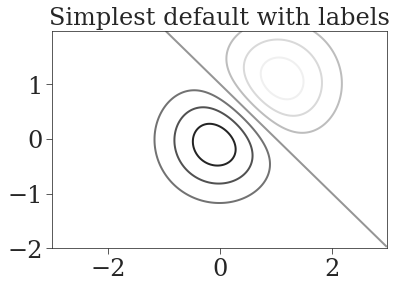

In [11]:
fig, ax = plt.subplots()
CS = ax.contour(X, Y, Z)
# ax.clabel(CS, inline=True, fontsize=10)
ax.set_title('Simplest default with labels')

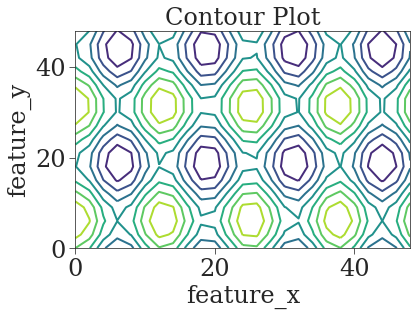

In [9]:
import matplotlib.pyplot as plt
import numpy as np
  
feature_x = np.arange(0, 50, 2)
feature_y = np.arange(0, 50, 3)
  
# Creating 2-D grid of features
[X, Y] = np.meshgrid(feature_x, feature_y)
  
fig, ax = plt.subplots(1, 1)
  
Z = np.cos(X / 2) + np.sin(Y / 4)
  
# plots contour lines
t = ax.contour(X, Y, Z, cmap='viridis')
  
ax.set_title('Contour Plot')
ax.set_xlabel('feature_x')
ax.set_ylabel('feature_y')
  
plt.show()